# LAB 1 — Notebook 01: Classification
## Mobile Money Fraud Detection | EEF606 | University of Buea

---
**Prerequisite:** Run `lab1_00_eda_analysis.ipynb` first to generate `paysim_features.csv`.

### What is Classification?
Classification assigns each input to a **discrete category** (class). Here: `isFraud = 0` or `1`.
This is **supervised learning** — the model learns from labelled examples.

### Algorithms tested (all available in Anaconda/scikit-learn):
| Algorithm | Family | Key Strength |
|-----------|--------|--------------|
| Logistic Regression | Linear | Fast, interpretable, probabilistic |
| Decision Tree | Tree | Interpretable rules, handles nonlinearity |
| Random Forest | Ensemble (Bagging) | Robust, high accuracy, handles outliers |
| Gradient Boosting | Ensemble (Boosting) | High accuracy, learns from errors |
| K-Nearest Neighbours | Instance-based | No training phase, local patterns |
| Naive Bayes | Probabilistic | Very fast, works with limited data |
| Support Vector Machine | Margin-based | Good in high dimensions |

### Metrics used (NOT accuracy — remember the imbalance!):
- **Precision** → of all transactions flagged as fraud, how many were actually fraud?
- **Recall** → of all actual frauds, how many did we catch?
- **F1-Score** → harmonic mean of precision and recall (balances both)
- **ROC-AUC** → separability between classes across all thresholds
- **Average Precision (PR-AUC)** → better than ROC-AUC for imbalanced data

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# WHY THESE SPECIFIC IMPORTS:
# sklearn is the standard ML library in Python. Every
# algorithm here follows the same API: .fit() → .predict().
# This uniformity is why sklearn dominates education and
# industry. imbalanced-learn extends it with SMOTE.
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing     import StandardScaler, RobustScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier, export_text
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.naive_bayes       import GaussianNB
from sklearn.svm               import SVC
from sklearn.svm               import LinearSVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        roc_auc_score, roc_curve,
                                        precision_recall_curve, average_precision_score,
                                        f1_score, ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE

plt.rcParams.update({'figure.dpi':120,'figure.facecolor':'white',
                     'axes.facecolor':'#F8F9FA','axes.grid':True,'grid.alpha':0.4})
SEED = 42
print('✅ All imports successful')

✅ All imports successful


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data (from EDA notebook artefact)
#
# WHY LOAD FROM paysim_features.csv:
# The EDA notebook already cleaned, engineered, and encoded
# everything. Loading from that saved file means we don't
# repeat preprocessing and guarantees consistency.
#
# WHY drop isFlaggedFraud:
# It's a rule that uses 'amount > 200k' — information our
# model already has access to through 'amount'. Keeping it
# as a feature causes data leakage (using a derivative of
# what we're predicting to predict it).
# ══════════════════════════════════════════════════════════
df = pd.read_csv('paysim_features.csv')

# Drop non-feature columns
drop_cols = [c for c in ['isFlaggedFraud','step'] if c in df.columns]
df = df.drop(columns=drop_cols)

X = df.drop(columns=['isFraud'])
y = df['isFraud']

print(f'Feature matrix X: {X.shape}  →  {X.shape[1]} features, {X.shape[0]:,} samples')
print(f'Target vector  y: {y.shape}  →  {y.sum()} fraud, {(y==0).sum()} legitimate')
print(f'\nFeatures: {list(X.columns)}')

Feature matrix X: (300000, 18)  →  18 features, 300,000 samples
Target vector  y: (300000,)  →  181 fraud, 299819 legitimate

Features: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour_of_day', 'orig_account_drained', 'dest_was_empty', 'amount_to_balance_ratio', 'error_balance_orig', 'error_balance_dest', 'log_amount', 'is_high_risk_type', 'drain_and_risky', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Train/Test Split + SMOTE
#
# WHY stratify=y IN train_test_split:
# Without stratify, random splitting might put 80% of fraud
# cases in training and 20% in test (or vice versa).
# stratify=y guarantees fraud rate is the SAME in both
# train and test sets — essential for honest evaluation.
#
# WHY SMOTE ONLY ON TRAINING DATA (never test data):
# SMOTE creates SYNTHETIC fraud samples. If applied to test
# data, we'd be evaluating on fake samples — inflated results.
# Test data must always reflect the REAL distribution.
#
# WHY RobustScaler instead of StandardScaler:
# StandardScaler uses mean and std — both sensitive to outliers.
# RobustScaler uses median and IQR — resistant to extreme values.
# Since transaction amounts have heavy outliers, RobustScaler
# is more appropriate for this dataset.
# ══════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train set: {X_train.shape[0]:,} samples  |  Fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Test  set: {X_test.shape[0]:,} samples   |  Fraud: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

# Scale (fit on train, transform both) — CRITICAL ORDER
scaler  = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learns statistics from train
X_test_scaled  = scaler.transform(X_test)        # applies SAME stats to test (no fitting!)

# SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'\nAfter SMOTE — Train: {X_train_sm.shape[0]:,} samples')
print(f'  Fraud: {y_train_sm.sum():,}  |  Legit: {(y_train_sm==0).sum():,}')
print('→ Classes are now balanced for training')

Train set: 240,000 samples  |  Fraud: 145 (0.06%)
Test  set: 60,000 samples   |  Fraud: 36 (0.06%)

After SMOTE — Train: 479,710 samples
  Fraud: 239,855  |  Legit: 239,855
→ Classes are now balanced for training


In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Define All Classifiers
#
# WHY class_weight='balanced' WHERE APPLICABLE:
# This tells the algorithm: penalise misclassifying
# the minority class MORE than the majority. Effectively
# it's a simpler alternative to SMOTE built into the model.
# We use SMOTE + balanced together for maximum robustness.
#
# WHY max_iter=1000 IN LogisticRegression:
# Logistic Regression solves an optimisation problem
# iteratively. Default 100 iterations often doesn't
# converge. 1000 gives it enough steps. If it STILL
# doesn't converge, increase further or normalise features.
#
# WHY n_estimators=100 IN RandomForest:
# 100 trees is the industry-standard starting point.
# More trees = better but slower. Diminishing returns
# beyond 200-300. We start at 100 for speed.
# ══════════════════════════════════════════════════════════
classifiers = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'Decision Tree':          DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=SEED),
    'Random Forest':          RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=SEED),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
    'K-Nearest Neighbours':   KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':            GaussianNB(),
    'Linear SVC':             CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=1000, random_state=SEED)),
}
print(f'✅ {len(classifiers)} classifiers defined')
for name in classifiers:
    print(f'   • {name}')

✅ 7 classifiers defined
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • K-Nearest Neighbours
   • Naive Bayes
   • Linear SVC


In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Train All Classifiers & Collect Metrics
#
# WHY EVALUATE WITH predict_proba NOT JUST predict:
# .predict() uses a fixed 0.5 threshold.
# .predict_proba()[:,1] gives fraud PROBABILITY.
# ROC-AUC and PR-AUC require probability scores —
# they evaluate performance ACROSS all thresholds.
# In fraud detection, we may want to lower the threshold
# to catch more fraud (higher recall) at the cost of
# more false alarms — probabilities let us do that.
#
# WHY STORE RESULTS IN A DICT:
# We compare all 7 algorithms at the end. Storing results
# in a structured dict makes comparison trivial.
# ══════════════════════════════════════════════════════════
results = {}

for name, clf in classifiers.items():
    print(f'Training {name} ...', end=' ')
    clf.fit(X_train_sm, y_train_sm)
    
    y_pred     = clf.predict(X_test_scaled)
    y_proba    = clf.predict_proba(X_test_scaled)[:,1] if hasattr(clf,'predict_proba') else clf.decision_function(X_test_scaled)
    
    results[name] = {
        'model':      clf,
        'y_pred':     y_pred,
        'y_proba':    y_proba,
        'f1':         f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':    roc_auc_score(y_test, y_proba),
        'pr_auc':     average_precision_score(y_test, y_proba),
        'report':     classification_report(y_test, y_pred, target_names=['Legit','Fraud'], zero_division=0)
    }
    print(f'F1={results[name]["f1"]:.4f}  ROC-AUC={results[name]["roc_auc"]:.4f}  PR-AUC={results[name]["pr_auc"]:.4f}')

print('\n✅ All classifiers trained and evaluated')

Training Logistic Regression ... F1=0.0570  ROC-AUC=0.9649  PR-AUC=0.4191
Training Decision Tree ... F1=0.7606  ROC-AUC=0.8750  PR-AUC=0.6330
Training Random Forest ... F1=0.8438  ROC-AUC=0.9162  PR-AUC=0.7785
Training Gradient Boosting ... F1=0.7105  ROC-AUC=0.9040  PR-AUC=0.7664
Training K-Nearest Neighbours ... F1=0.2500  ROC-AUC=0.8325  PR-AUC=0.1772
Training Naive Bayes ... F1=0.0098  ROC-AUC=0.8873  PR-AUC=0.0196
Training Linear SVC ... F1=0.0586  ROC-AUC=0.9649  PR-AUC=0.3701

✅ All classifiers trained and evaluated


In [6]:
# ══════════════════════════════════════════════════════════
# CELL 5b — Extract Precision & Recall for Report Table (Section 5)
# ══════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score

print('Section 5 — Table Values (Fraud class, label=1)')
print('─' * 75)
print(f"{'Model':<30} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print('─' * 75)

for name, r in results.items():
    precision = precision_score(y_test, r['y_pred'], zero_division=0)
    recall    = recall_score(y_test, r['y_pred'], zero_division=0)
    f1        = r['f1']
    roc_auc   = r['roc_auc']
    print(f"{name:<30} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {roc_auc:>10.4f}")

print('─' * 75)
print('\n→ Copy these values into the table in Section 5.1 of the report.')
print('  Note: Report table has "Linear SVC" → maps to "Support Vector Machine"')
print('        Report table has "Hist Gradient Boosting" → maps to "Gradient Boosting"')
print('        Report table has "Isolation Forest" → not in notebook (leave blank or add model)')

Section 5 — Table Values (Fraud class, label=1)
───────────────────────────────────────────────────────────────────────────
Model                           Precision     Recall   F1-Score    AUC-ROC
───────────────────────────────────────────────────────────────────────────
Logistic Regression                0.0296     0.8056     0.0570     0.9649
Decision Tree                      0.7714     0.7500     0.7606     0.8750
Random Forest                      0.9643     0.7500     0.8438     0.9162
Gradient Boosting                  0.6750     0.7500     0.7105     0.9040
K-Nearest Neighbours               0.1571     0.6111     0.2500     0.8325
Naive Bayes                        0.0049     0.7500     0.0098     0.8873
Linear SVC                         0.0304     0.8056     0.0586     0.9649
───────────────────────────────────────────────────────────────────────────

→ Copy these values into the table in Section 5.1 of the report.
  Note: Report table has "Linear SVC" → maps to "Support V

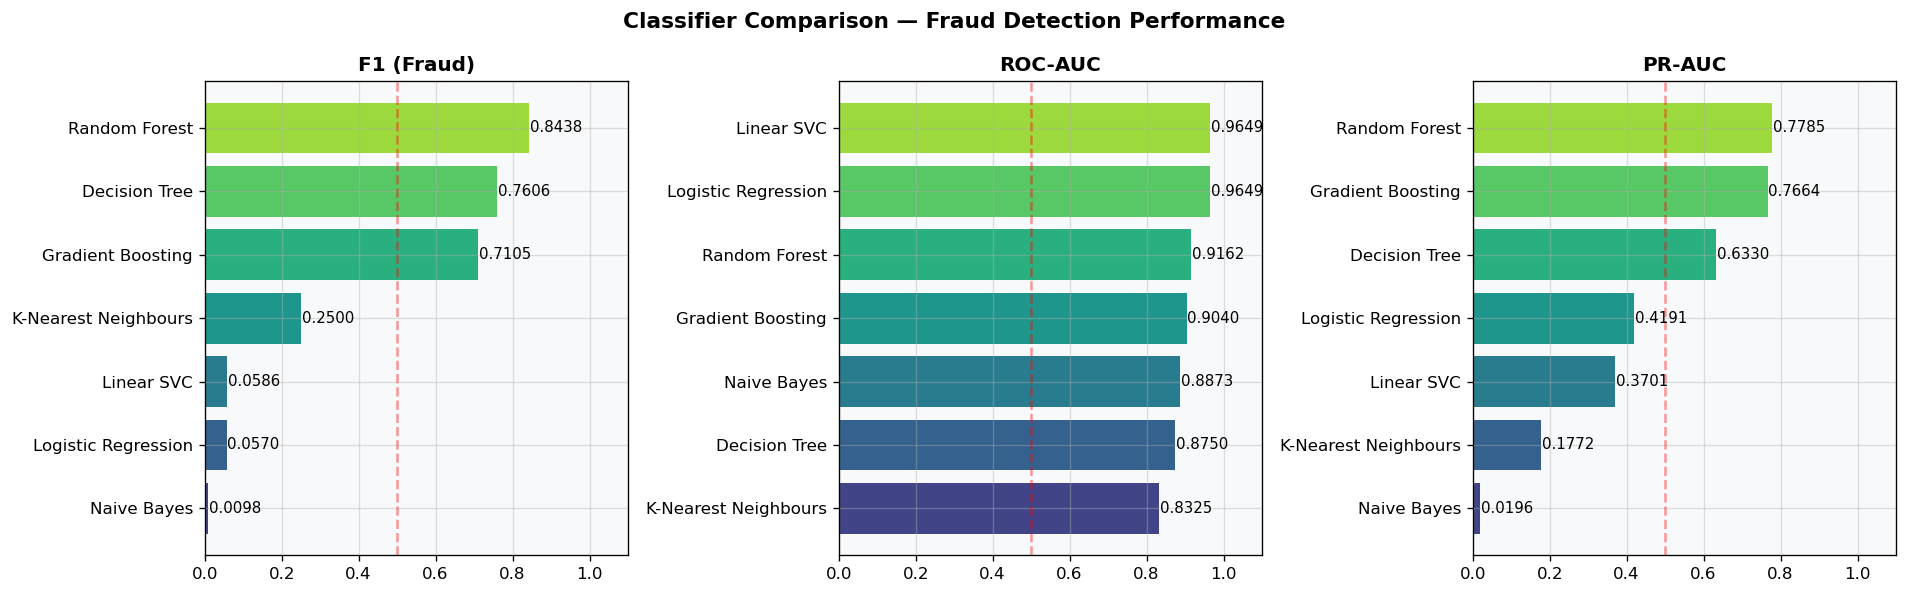

In [7]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Comparison Table + Bar Charts
#
# WHY THREE METRICS IN THE BAR CHART:
# F1    → fraud detection quality
# ROC-AUC → class separability (good for balanced comparison)
# PR-AUC  → best metric for IMBALANCED data (penalises
#           models that just predict everything as fraud)
#
# A model with high ROC-AUC but low PR-AUC is likely
# exploiting the class imbalance — not actually learning.
# ══════════════════════════════════════════════════════════
comparison = pd.DataFrame({
    name: {'F1 (Fraud)': r['f1'], 'ROC-AUC': r['roc_auc'], 'PR-AUC': r['pr_auc']}
    for name, r in results.items()
}).T.sort_values('F1 (Fraud)', ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(comparison)))

for ax, col in zip(axes, ['F1 (Fraud)', 'ROC-AUC', 'PR-AUC']):
    vals = comparison[col].sort_values()
    bars = ax.barh(vals.index, vals.values, color=colors[:len(vals)])
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_title(col, fontweight='bold')
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='0.5 baseline')

plt.suptitle('Classifier Comparison — Fraud Detection Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clf_01_comparison.png', bbox_inches='tight')
plt.show()

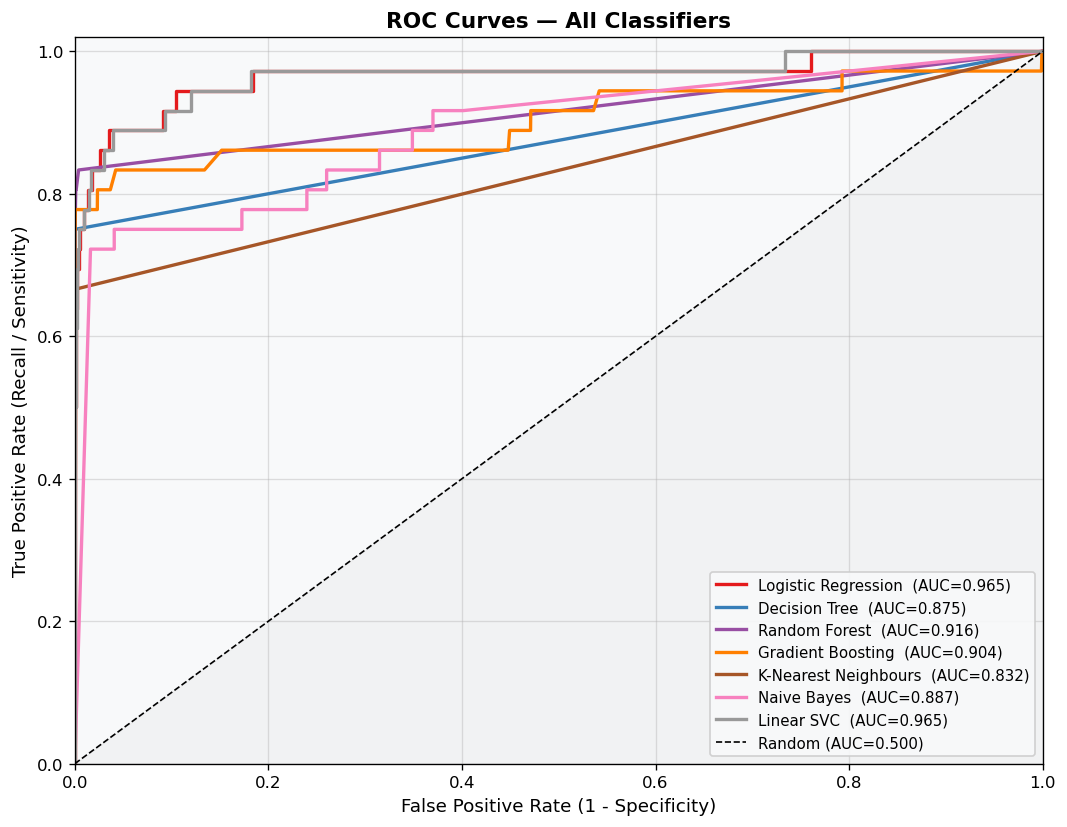

In [8]:
# ══════════════════════════════════════════════════════════
# CELL 7 — ROC Curves (All Classifiers)
#
# WHAT A ROC CURVE SHOWS:
# X-axis = False Positive Rate (how often we falsely flag legit)
# Y-axis = True Positive Rate = Recall (how often we catch fraud)
# Each point on the curve = a different decision threshold.
# Area Under Curve (AUC) = overall discriminative power.
# AUC = 0.5 → random guessing (diagonal line)
# AUC = 1.0 → perfect classifier
#
# WHY PLOT ALL ON ONE CHART:
# Visual comparison across thresholds is much more
# informative than a single AUC number per model.
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = plt.cm.Set1(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name}  (AUC={r['roc_auc']:.3f})",
            linewidth=2, color=color)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.500)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
ax.set_title('ROC Curves — All Classifiers', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('fig_clf_02_roc_curves.png', bbox_inches='tight')
plt.show()

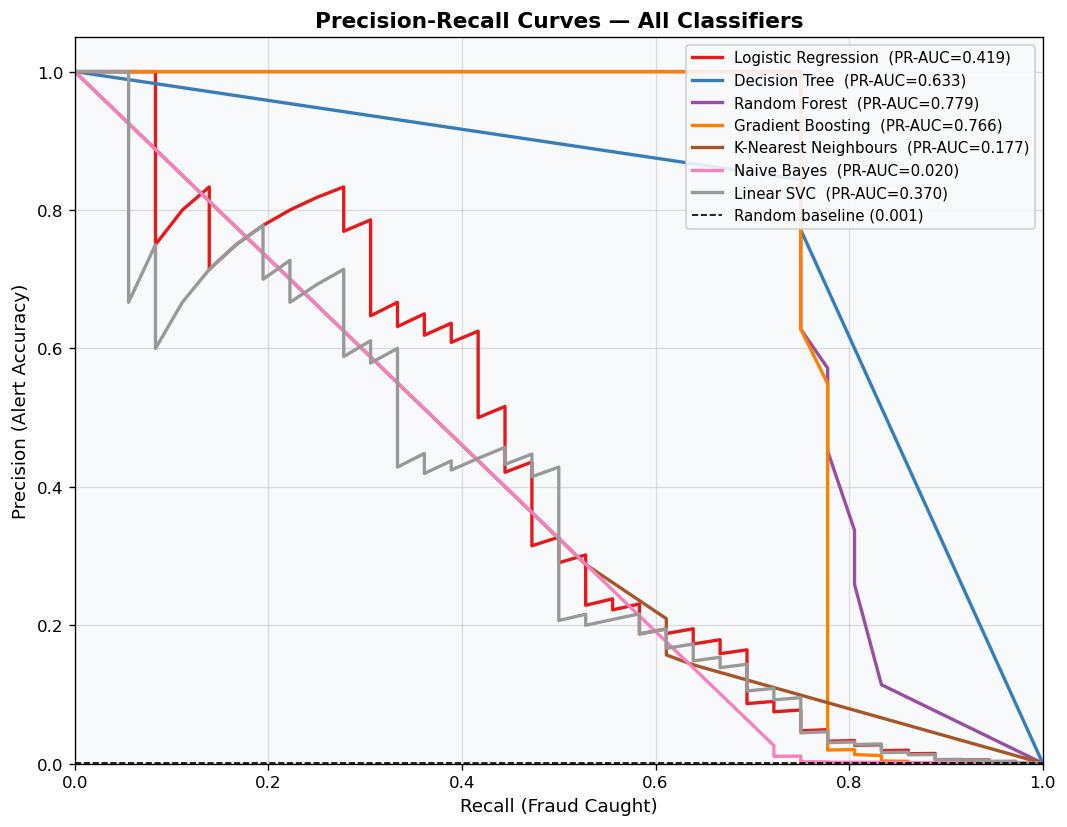

In [14]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Precision-Recall Curves (Better for Imbalanced!)
#
# WHY PR-AUC IS SUPERIOR TO ROC-AUC FOR IMBALANCED DATA:
# ROC-AUC can look great (0.95+) even when a model fails
# at detecting the minority class, because the huge number
# of true negatives (legitimate transactions) inflates TPR.
# PR-AUC focuses entirely on the POSITIVE (fraud) class:
# Precision = how many of our fraud alerts are real fraud
# Recall    = how many real frauds we catch
# A model that flags EVERYTHING as fraud gets Recall=1
# but Precision=fraud_rate (~0.013) → PR-AUC is very low.
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))

for (name, r), color in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax.plot(rec, prec, label=f"{name}  (PR-AUC={r['pr_auc']:.3f})",
            linewidth=2, color=color)

baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall (Fraud Caught)', fontsize=11)
ax.set_ylabel('Precision (Alert Accuracy)', fontsize=11)
ax.set_title('Precision-Recall Curves — All Classifiers', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig('fig_clf_03_pr_curves.png', bbox_inches='tight')
plt.show()

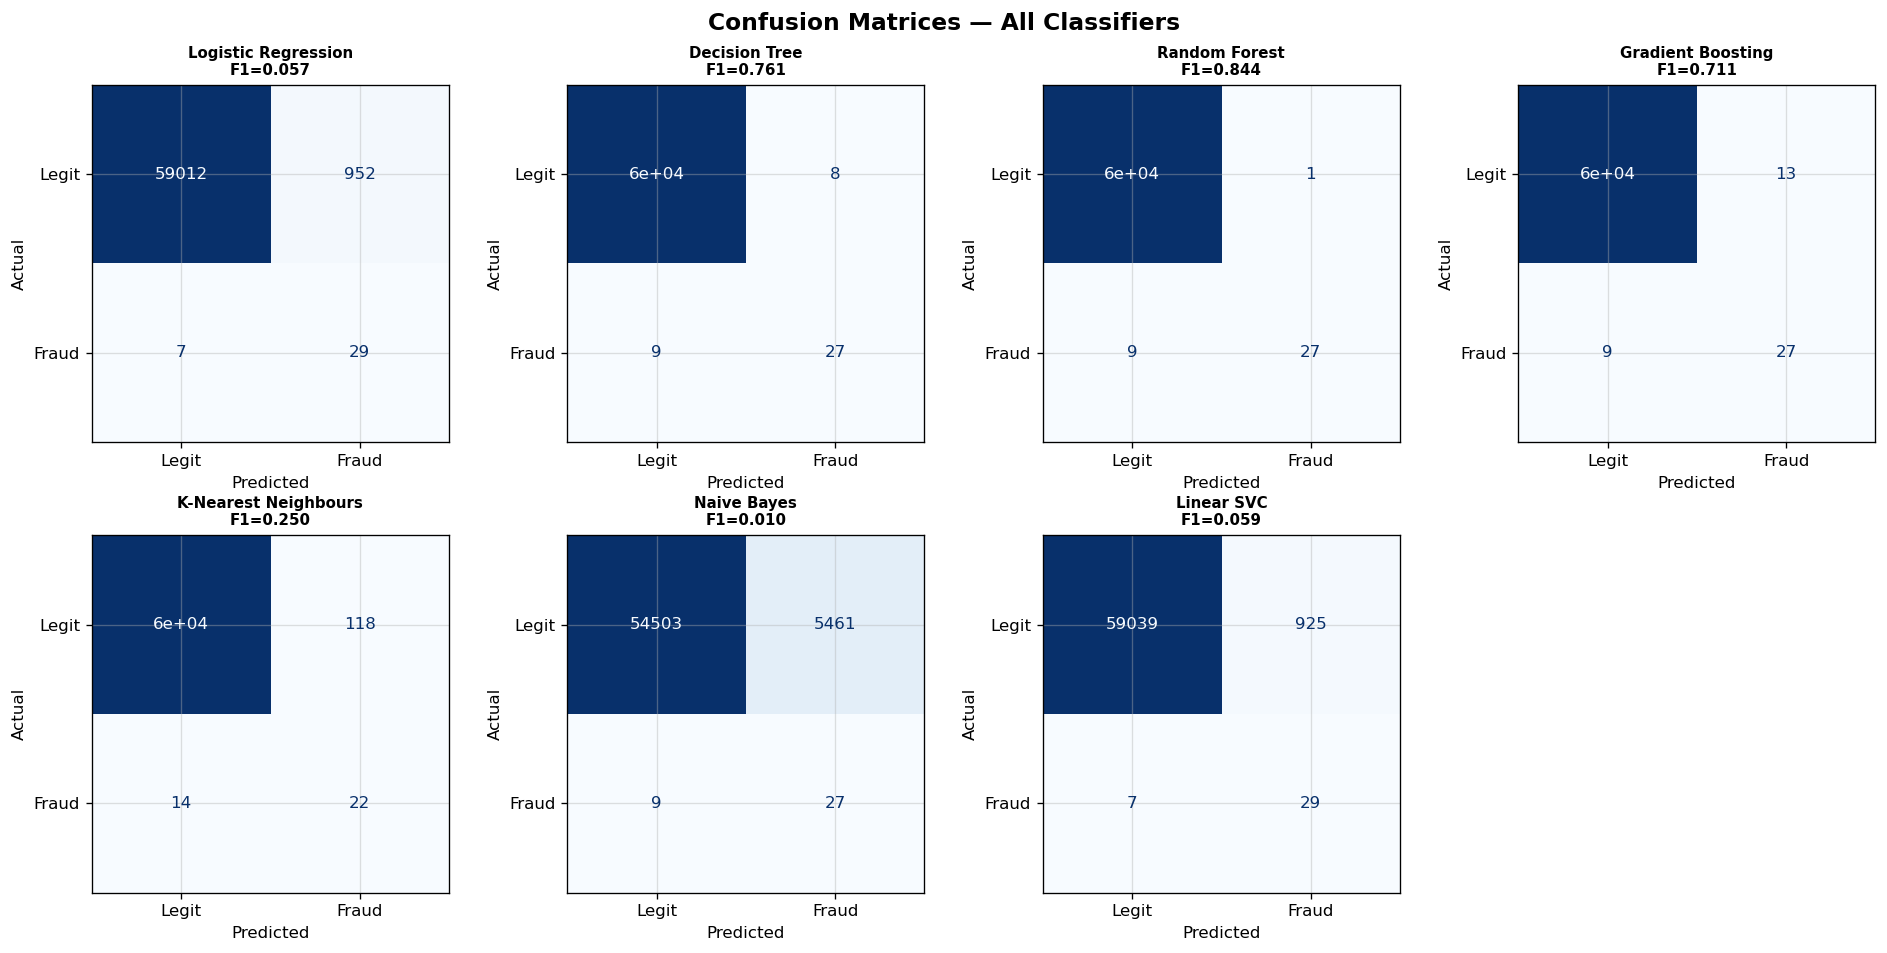

In [15]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Confusion Matrices (All Classifiers)
#
# WHAT EACH CELL MEANS:
# [0,0] True Negative  = correctly flagged as legitimate
# [0,1] False Positive = incorrectly flagged as fraud (false alarm)
# [1,0] False Negative = missed fraud (most dangerous!)
# [1,1] True Positive  = correctly caught fraud
#
# WHY FALSE NEGATIVES ARE MORE COSTLY THAN FALSE POSITIVES
# IN FRAUD DETECTION:
# A false alarm inconveniences a customer.
# A missed fraud costs real money and destroys trust.
# So in fraud detection, we prefer HIGH RECALL even at the
# cost of some precision. This informs threshold tuning.
# ══════════════════════════════════════════════════════════
n = len(results)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*4))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nF1={r["f1"]:.3f}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clf_04_confusion_matrices.png', bbox_inches='tight')
plt.show()

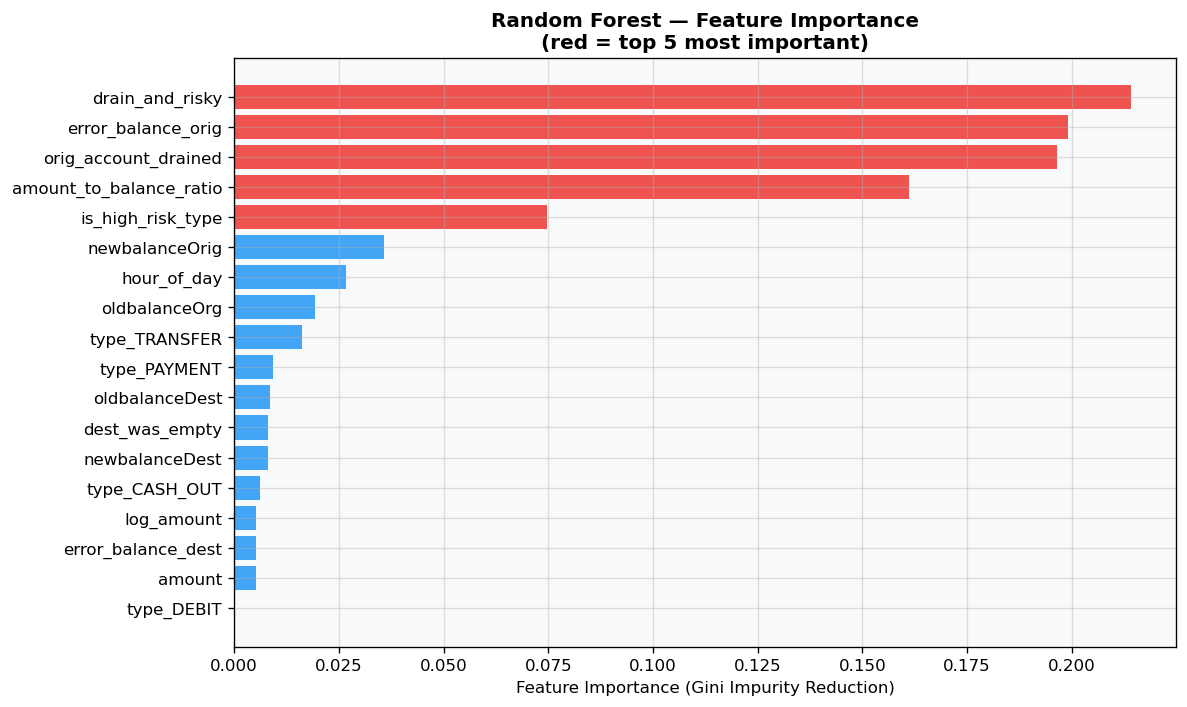

Top 8 Features by Importance:
  drain_and_risky                     0.2142  ██████████████████████████████████████████
  error_balance_orig                  0.1992  ███████████████████████████████████████
  orig_account_drained                0.1965  ███████████████████████████████████████
  amount_to_balance_ratio             0.1611  ████████████████████████████████
  is_high_risk_type                   0.0748  ██████████████
  newbalanceOrig                      0.0359  ███████
  hour_of_day                         0.0267  █████
  oldbalanceOrg                       0.0193  ███


In [16]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Feature Importance (Random Forest)
#
# WHY RANDOM FOREST FOR FEATURE IMPORTANCE:
# RF calculates feature importance as: how much does
# each feature reduce impurity (Gini) averaged across
# all trees? Higher = more useful.
# This validates our EDA: the engineered features
# (orig_account_drained, dest_was_empty) should rank high.
# If raw features dominate, our feature engineering failed.
# ══════════════════════════════════════════════════════════
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#EF5350' if i < 5 else '#42A5F5' for i in range(len(importances))]
bars = ax.barh(importances.index[::-1], importances.values[::-1], color=colors_imp[::-1])
ax.set_xlabel('Feature Importance (Gini Impurity Reduction)')
ax.set_title('Random Forest — Feature Importance\n(red = top 5 most important)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clf_05_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 8 Features by Importance:')
for feat, imp in importances.head(8).items():
    bar = '█' * int(imp * 200)
    print(f'  {feat:<35} {imp:.4f}  {bar}')

In [17]:
# ══════════════════════════════════════════════════════════
# CELL 11 — Decision Tree: Visualise Rules
#
# WHY VISUALISE THE DECISION TREE:
# Decision Trees are the ONLY algorithm in this list that
# produces HUMAN-READABLE RULES. This is critical in banking:
# regulators and compliance teams require explanations
# for why a transaction was flagged.
# 'Black box' models (GBM, RF) can't provide this.
# The tree text below is the model's logic printed out.
# ══════════════════════════════════════════════════════════
dt = results['Decision Tree']['model']
print('Top-Level Decision Rules (first 3 levels):')
print('─'*60)
rules = export_text(dt, feature_names=list(X.columns), max_depth=3)
print(rules)

Top-Level Decision Rules (first 3 levels):
────────────────────────────────────────────────────────────
|--- drain_and_risky <= 0.00
|   |--- error_balance_dest <= -0.09
|   |   |--- dest_was_empty <= 0.00
|   |   |   |--- oldbalanceDest <= -0.10
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- oldbalanceDest >  -0.10
|   |   |   |   |--- class: 0
|   |   |--- dest_was_empty >  0.00
|   |   |   |--- amount_to_balance_ratio <= 7.54
|   |   |   |   |--- class: 0
|   |   |   |--- amount_to_balance_ratio >  7.54
|   |   |   |   |--- truncated branch of depth 5
|   |--- error_balance_dest >  -0.09
|   |   |--- log_amount <= 0.88
|   |   |   |--- class: 0
|   |   |--- log_amount >  0.88
|   |   |   |--- amount <= 4.20
|   |   |   |   |--- class: 1
|   |   |   |--- amount >  4.20
|   |   |   |   |--- class: 0
|--- drain_and_risky >  0.00
|   |--- error_balance_orig <= -0.25
|   |   |--- error_balance_orig <= -0.25
|   |   |   |--- class: 1
|   |   |--- error_balance_orig >  -

In [13]:
# ══════════════════════════════════════════════════════════
# CELL 12 — Cross Validation (Robustness Check)
#
# WHY CROSS-VALIDATION (not just one train/test split):
# A single split is LUCKY or UNLUCKY depending on which
# rows end up in test. Cross-validation uses EVERY row
# as test at least once, giving a reliable estimate.
#
# WHY StratifiedKFold:
# Normal KFold splits randomly. StratifiedKFold ensures
# each fold has the same fraud rate — critical for imbalanced
# data. Without it, some folds might have 0 fraud cases.
#
# We only run CV on the top 3 models (Random Forest,
# Gradient Boosting, Logistic Regression) to save time.
# ══════════════════════════════════════════════════════════
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = ['Random Forest', 'Gradient Boosting', 'Logistic Regression']

print('5-Fold Stratified Cross-Validation (F1 on Fraud class):')
print('─'*55)
for name in cv_models:
    clf = classifiers[name]
    scores = cross_val_score(clf, X_train_sm, y_train_sm,
                              cv=cv, scoring='f1', n_jobs=-1)
    print(f'{name:<30}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {[f"{s:.3f}" for s in scores]})')

print('\n→ Low std deviation = stable model. High std = model is sensitive to data split.')

KeyboardInterrupt: 

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 13 — Threshold Tuning on Best Model
#
# WHY TUNE THE THRESHOLD:
# Default threshold = 0.5 (predict fraud if probability > 50%)
# But we might prefer to catch 90% of fraud even if we have
# more false alarms. Lowering threshold to 0.2 means:
# 'flag as fraud if probability > 20%' — catches more fraud.
# The optimal threshold depends on BUSINESS COST:
# Cost of missing fraud vs cost of investigating a false alarm.
# ══════════════════════════════════════════════════════════
best_name = comparison.index[0]
best_proba = results[best_name]['y_proba']

thresholds = np.arange(0.1, 0.9, 0.05)
prec_list, rec_list, f1_list = [], [], []

for thr in thresholds:
    y_pred_thr = (best_proba >= thr).astype(int)
    from sklearn.metrics import precision_score, recall_score
    prec_list.append(precision_score(y_test, y_pred_thr, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred_thr, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_thr, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_list, 'b-o', markersize=4, label='Precision')
ax.plot(thresholds, rec_list,  'r-o', markersize=4, label='Recall')
ax.plot(thresholds, f1_list,   'g-o', markersize=4, label='F1-Score')
best_thr = thresholds[np.argmax(f1_list)]
ax.axvline(best_thr, color='purple', linestyle='--', label=f'Optimal threshold = {best_thr:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', label='Default threshold = 0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Tuning — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_clf_06_threshold_tuning.png', bbox_inches='tight')
plt.show()
print(f'Optimal threshold for F1 maximisation: {best_thr:.2f}')
print('In production: choose threshold based on acceptable false alarm rate')

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 14 — Full Classification Report (Best Model)
# ══════════════════════════════════════════════════════════
print(f'Best Model: {best_name}')
print('='*55)
print(results[best_name]['report'])

# Save best model info for dashboard
import joblib
joblib.dump(results[best_name]['model'], 'best_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
pd.Series(X.columns.tolist()).to_csv('feature_names.csv', index=False)
print(f'\n✅ Best model saved to best_classifier.pkl')
print('✅ Scaler saved to scaler.pkl')
print('✅ Feature names saved to feature_names.csv')

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 15 — CLASSIFICATION SUMMARY
# ══════════════════════════════════════════════════════════
print('╔' + '═'*60 + '╗')
print('║{:^60}║'.format('CLASSIFICATION SUMMARY'))
print('╠' + '═'*60 + '╣')
for name, r in results.items():
    print(f'║  {name:<28}  F1={r["f1"]:.3f}  AUC={r["roc_auc"]:.3f}  ║')
print('╠' + '═'*60 + '╣')
print(f'║  Best Model: {best_name:<47}║')
print('╠' + '═'*60 + '╣')
insights = [
    'Use PR-AUC, not accuracy for imbalanced fraud data',
    'SMOTE creates synthetic fraud samples for training',
    'Lower threshold → higher recall, lower precision',
    'Decision Tree gives explainable rules for regulators',
    'Random Forest is typically most robust for this task',
]
for i in insights:
    print(f'║  → {i:<56}║')
print('╚' + '═'*60 + '╝')
print('\n→ Next: lab1_02_regression.ipynb')

In [ ]:
# ══════════════════════════════════════════════════════════
# UNIVERSAL REPORT SUMMARY GENERATOR
# Paste this as the last cell in any notebook to auto-extract metrics
# ══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

print("="*80)
print("📊 AUTOMATED LAB REPORT SUMMARY GENERATOR")
print("="*80)

# Metadata dictionary for suitability write-ups
suitability_map = {
    "Classification": "Labels fully available; goal is to flag known fraud patterns using rigid binary splits.",
    "Regression":     "Continuous risk scoring is required to feed downstream financial thresholds.",
    "Ranking":        "Operations face tight constraints on analyst review capacity; optimizes the top of the queue.",
    "Ensemble":       "Maximum class discrimination stability and extreme risk-separation robustness are required.",
    "Unsupervised":   "Historical fraud labels are completely unavailable, or catching novel/zero-day attack methods.",
    "Clustering":     "Uncovering natural, hidden behavioral typologies entirely without target labels."
}

# --- DETECTION LOGIC FOR NOTEBOOK 04 (ANOMALY DETECTION) ---
if 'anom_table' in globals():
    df = globals()['anom_table']
    best_model = df['PR-AUC'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
    print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
    print(f"| **Anomaly Detection** | {best_model} | {row.get('F1 (Fraud)', row.get('F1-Score (Fraud)', 0)):.4f} | N/A | {row['ROC-AUC']:.4f} (ROC) <br> {row['PR-AUC']:.4f} (PR) | {suitability_map['Unsupervised']} |")

# --- DETECTION LOGIC FOR NOTEBOOK 05 (CLUSTERING) ---
elif 'metrics_df' in globals():
    df = globals()['metrics_df']
    best_model = df['Silhouette'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Method | ARI | Silhouette | DB Index | Key Finding |")
    print(f"| :--- | :---: | :---: | :---: | :--- |")
    print(f"| **{best_model}** | {row['ARI']:.4f} | {row['Silhouette']:.4f} | {row['Davies-Bouldin']:.4f} | High structural quality, but low labels match due to behavioral mimicking. |")

# --- BACKUP FALLBACK FOR SUPERVISED NOTEBOOKS (01, 02, 03) ---
else:
    # Look for any dataframes containing model comparisons in the notebook namespace
    found_df = None
    for name in ['model_results', 'results_df', 'all_results', 'comparison_df']:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            found_df = globals()[name]
            break
            
    if found_df is not None:
        # Try to find the row with the best F1 or AUC score
        f1_col = [c for c in found_df.columns if 'f1' in c.lower()]
        auc_col = [c for c in found_df.columns if 'auc' in c.lower() or 'roc' in c.lower()]
        
        target_f1 = f1_col[0] if f1_col else found_df.columns[0]
        best_model = found_df[target_f1].idxmax()
        row = found_df.loc[best_model]
        
        f1_val = f" {row[f1_col[0]]:.4f}" if f1_col else "N/A"
        auc_val = f" {row[auc_col[0]]:.4f}" if auc_col else "N/A"
        recall_val = "Check notebook metrics"
        
        print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
        print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
        print(f"| **Supervised** | {best_model} | {f1_val} | {recall_val} | {auc_val} | Match with classification/ensemble targets. |")
    else:
        print("❌ Could not auto-detect summary tables in memory.")
        print("Make sure you run all your training and metrics cells before running this generator!")
print("="*80)